# Advanced Machine Learning - Project 1

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    recall_score, precision_score, f1_score, balanced_accuracy_score,
    roc_auc_score, auc, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

In [28]:
from src.data_generation import DataGenerator
from src.fista import FistaLogisticRegression

## FISTA Algorithm (Fast Iterative Shrinkage-Thresholding Algorithm)

The FISTA (Fast Iterative Shrinkage-Thresholding Algorithm) algorithm is used to optimize problems that can be split into two parts: a smooth (differentiable) part and a non-smooth (non-differentiable but convex) part.

### Problem Formulation

$$\min_{\mathbf{w}, b} F(\mathbf{w}, b) = f(\mathbf{w}, b) + g(\mathbf{w})$$

**Smooth part** $f(\mathbf{w}, b)$ (logistic loss for binary classification $y_i \in \{-1, 1\}$):
$$f(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \log(1+e^{-y_i(\mathbf{w}^T\mathbf{x}_i+b)})$$

**Non-smooth part** $g(\mathbf{w})$ (L1 penalty):
$$g(\mathbf{w}) = \lambda\|\mathbf{w}\|_1$$

### FISTA Steps
The paper by Beck & Teboulle (2009) outlines "FISTA with constant stepsize" using the following steps:
- Input: $L = L(f)$ — A Lipschitz constant of $\nabla f$.
- Step 0: Take $y_1 = x_0 \in \mathbb{R}^n$, $t_1 = 1$.
- Step $k$ ($k \ge 1$): Compute:
    1. $x_k = p_L(y_k)$ 
    2. $t_{k+1} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$ 
    3. $y_{k+1} = x_k + \left(\frac{t_k - 1}{t_{k+1}}\right)(x_k - x_{k-1})$ 


In the paper, the Proximal Operator ($p_L$) is the core building block of both ISTA and FISTA. It is introduced in Section 2.3 ("The basic approximation model"). With some algebraic manipulation, the authors show that the proximal step can be simplified to a shrinkage (soft-thresholding) operation when the non-smooth part is the L1 norm:

$$p_L(y) = \mathcal{T}_{\lambda/L} \left( y - \frac{1}{L} \nabla f(y) \right)$$

where 

$$\mathcal{T}_{\alpha}(z) = \text{sign}(z) \cdot \max(|z| - \alpha, 0)$$
 is the shrinkage operator.

### Algorithm implementation 

**Initialization:** `x_prev = 0`, `b_prev = 0`, `y_k = x_prev`, `y_k_b = b_prev`, `t_k = 1`

**For each iteration:**

#### Step 1: Compute Gradient
```
grad_x, grad_b = _compute_gradient(X, y, y_k, y_k_b)
```

$$z = \mathbf{X} \cdot \mathbf{y}_k + y_{k, b}$$
$$y_{\text{signed}} = 2 \cdot y - 1$$
$$\text{pred} = \sigma(y_{\text{signed}} \cdot z)$$
$$\text{errors} = (\text{pred} - 1) \cdot y_{\text{signed}}$$
$$\text{grad\_x} = \frac{\mathbf{X}^T \cdot \text{errors}}{n}, \quad \text{grad\_b} = \frac{1}{n}\sum \text{errors}$$

#### Step 2: Gradient Descent
```
x_temp = y_k - learning_rate * grad_x
```

$$\mathbf{x}_{\text{temp}} = \mathbf{y}_k - \alpha \cdot \text{grad\_x}$$

#### Step 3: Soft Thresholding
```
x_k = _soft_threshold(x_temp, learning_rate * lambda_)
b_k = y_k_b - learning_rate * grad_b
```

$$\mathbf{x}_k = \text{sign}(\mathbf{x}_{\text{temp}}) \max(|\mathbf{x}_{\text{temp}}| - \alpha \lambda, 0)$$

#### Step 4: Nesterov Acceleration
```
t_next = (1.0 + sqrt(1.0 + 4.0 * t_k**2)) / 2.0
momentum_coeff = (t_k - 1.0) / t_next
```

$$t_{\text{next}} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$$
$$\text{momentum\_coeff} = \frac{t_k - 1}{t_{\text{next}}}$$

#### Step 5: Momentum Update
```
y_k = x_k + momentum_coeff * (x_k - x_prev)
y_k_b = b_k + momentum_coeff * (b_k - b_prev)
```

$$\mathbf{y}_k = \mathbf{x}_k + \text{momentum\_coeff} \cdot (\mathbf{x}_k - \mathbf{x}_{\text{prev}})$$

**Convergence Check & State Update:** 
```
if norm(x_k - x_prev) < tol: break
x_prev = x_k.copy()
b_prev = b_k
t_k = t_next
```

$$\|\mathbf{x}_k - \mathbf{x}_{\text{prev}}\|_2 < \text{tol}$$


**Learning Rate:** 
```
L = norm(X, ord=2)**2 / (4.0 * n)
```

$$L = \frac{\|\mathbf{X}\|_2^2}{4n}$$
which is the Lipschitz constant of $\nabla f$ for logistic regression.

```
learning_rate = 1.0 / L if L > 0 else 0.01
```
$$\alpha = \frac{1}{L}$$


## Experiments on Multiple Datasets

We evaluate the FISTA algorithm on 4 different datasets with various missing data mechanisms.


In [29]:
# Load all datasets
datasets = {}

dataset_info = {
    'Madelon': 'data/madelon/madelon_processed.csv',
    'Car Eval': 'data/car_eval/car_eval_processed.csv',
    'Speed Dating': 'data/speed_dating/speed_dating_processed.csv',
    'Student Performance': 'data/stud_perf/students_processed.csv'
}

for name, path in dataset_info.items():
    try:
        data = pd.read_csv(path)
        datasets[name] = data
        print(f"{name:25} - Shape: {data.shape}")
    except FileNotFoundError:
        print(f"{name:25} - File not found: {path}")


Madelon                   - Shape: (2600, 501)
Car Eval                  - Shape: (1728, 16)
Speed Dating              - Shape: (8378, 330)
Student Performance       - Shape: (395, 27)


In [30]:
def prepare_dataset(data, test_size_1=0.4, test_size_2=0.5, random_state=42):
    """
    Prepare a dataset: extract features and labels, split into train/valid/test,
    standardize features, and convert labels to binary.
    """
    X = data.drop(columns=['Y']).values
    y = data['Y'].values
    
    # Train-validation-test split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size_1, random_state=random_state
    )
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size_2, random_state=random_state
    )
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert to binary labels
    y_train_binary = (y_train > 0.5).astype(int)
    y_valid_binary = (y_valid > 0.5).astype(int)
    y_test_binary = (y_test > 0.5).astype(int)
    
    return {
        'X_train': X_train_scaled,
        'X_valid': X_valid_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train_binary,
        'y_valid': y_valid_binary,
        'y_test': y_test_binary
    }

# Prepare all datasets
prepared_datasets = {}
print("Preparing datasets...\n")

for name, data in datasets.items():
    prepared_datasets[name] = prepare_dataset(data)
    print(f"{name:25} - Train: {prepared_datasets[name]['X_train'].shape}, "
          f"Valid: {prepared_datasets[name]['X_valid'].shape}, "
          f"Test: {prepared_datasets[name]['X_test'].shape}")


Preparing datasets...

Madelon                   - Train: (1560, 500), Valid: (520, 500), Test: (520, 500)
Car Eval                  - Train: (1036, 15), Valid: (346, 15), Test: (346, 15)
Speed Dating              - Train: (5026, 329), Valid: (1676, 329), Test: (1676, 329)
Student Performance       - Train: (237, 26), Valid: (79, 26), Test: (79, 26)


In [31]:
def apply_missing_mechanism(y, X_shape, mechanism_name, seed):
    """
    Apply a missing data mechanism to labels.
    Missing labels are marked as -1.
    """
    if mechanism_name == 'Complete':
        return y.copy()
    
    dg = DataGenerator(p=X_shape, n=len(y), seed=seed)
    _, missing_indicator = getattr(dg, mechanism_name)()
    
    return np.where(missing_indicator == -1, -1, y)

mechanisms = ['MCAR', 'MAR1', 'MAR2', 'MNAR', 'Complete']

# Generate missing data for all datasets
missing_data_by_dataset = {}

print("Generating missing data mechanisms for all datasets...\n")

for dataset_name, prepared_data in prepared_datasets.items():
    X_shape = prepared_data['X_train'].shape[1]
    y_train = prepared_data['y_train']
    y_valid = prepared_data['y_valid']
    y_test = prepared_data['y_test']
    
    missing_mechanisms = {
        name: (
            apply_missing_mechanism(y_train, X_shape, name, seed=42),
            apply_missing_mechanism(y_valid, X_shape, name, seed=43),
            apply_missing_mechanism(y_test, X_shape, name, seed=44)
        )
        for name in mechanisms
    }
    
    missing_data_by_dataset[dataset_name] = missing_mechanisms


Generating missing data mechanisms for all datasets...



In [32]:
# Train FISTA models on all datasets with different missing mechanisms
lambda_range = np.logspace(-4, 1, 25)
measure = 'roc_auc'

# Dictionary structure: {dataset_name: {mechanism_name: {results}}}
all_fista_models = {}
all_results = {}

print("Training FISTA models on all datasets and missing mechanisms...\n")

for dataset_name, prepared_data in prepared_datasets.items():
    
    X_train = prepared_data['X_train']
    X_valid = prepared_data['X_valid']
    X_test = prepared_data['X_test']
    
    missing_mechanisms = missing_data_by_dataset[dataset_name]
    
    fista_models_dict = {}
    results_dict = {}
    
    for mechanism_name, (y_train_mech, y_valid_mech, y_test_mech) in missing_mechanisms.items():
        # Count observed labels
        n_obs_train = np.sum(y_train_mech != -1)
        n_obs_valid = np.sum(y_valid_mech != -1)
        missing_rate_train = 1 - n_obs_train / len(y_train_mech)
        missing_rate_valid = 1 - n_obs_valid / len(y_valid_mech)
        
        # Train FISTA
        fista_model = FistaLogisticRegression(
            max_iter=1000,
            lambda_range=lambda_range,
            measure=measure,
            X_valid=X_valid,
            y_valid=y_valid_mech
        )
        
        fista_model.fit(X_train, y_train_mech)
        fista_models_dict[mechanism_name] = fista_model
        
        # Evaluate on test set
        test_mask = y_test_mech != -1
        if np.sum(test_mask) > 0:
            X_test_obs = X_test[test_mask]
            y_test_obs = y_test_mech[test_mask]
            
            proba = fista_model.predict_proba(X_test_obs)[:, 1]
            y_pred = fista_model.predict(X_test_obs)
            
            test_auc = roc_auc_score(y_test_obs, proba)
            test_f1 = f1_score(y_test_obs, y_pred, zero_division=0)
            test_recall = recall_score(y_test_obs, y_pred, zero_division=0)
            test_precision = precision_score(y_test_obs, y_pred, zero_division=0)
            
            results_dict[mechanism_name] = {
                'missing_rate_train': missing_rate_train,
                'missing_rate_valid': missing_rate_valid,
                'best_lambda': fista_model.best_lambda_,
                'valid_auc': max(fista_model.validation_scores_[measure]),
                'test_auc': test_auc,
                'test_f1': test_f1,
                'test_recall': test_recall,
                'test_precision': test_precision
            }
            
    
    all_fista_models[dataset_name] = fista_models_dict
    all_results[dataset_name] = pd.DataFrame(results_dict).T



Training FISTA models on all datasets and missing mechanisms...



In [33]:
for dataset_name, results_df in all_results.items():
    print(f"\n{dataset_name}")
    print("-" * 80)
    display(results_df.round(6))



Madelon
--------------------------------------------------------------------------------


,missing_rate_train,missing_rate_valid,best_lambda,valid_auc,test_auc,test_f1,test_recall,test_precision
MCAR,0.113462,0.119231,0.031623,0.688791,0.590995,0.573276,0.583333,0.563559
MAR1,0.493590,0.507692,0.082540,0.656596,0.659392,0.571429,0.523810,0.628571
MAR2,0.512179,0.501923,0.051090,0.641434,0.588031,0.577075,0.565891,0.588710
MNAR,0.577564,0.567308,0.051090,0.663185,0.614638,0.625514,0.703704,0.562963
Complete,0.000000,0.000000,0.031623,0.681645,0.600911,0.583493,0.582375,0.584615



Car Eval
--------------------------------------------------------------------------------


,missing_rate_train,missing_rate_valid,best_lambda,valid_auc,test_auc,test_f1,test_recall,test_precision
MCAR,0.115830,0.083815,0.000100,0.994360,0.993077,0.935961,0.950000,0.922330
MAR1,0.491313,0.500000,0.004642,0.995339,0.994949,0.936937,0.962963,0.912281
MAR2,0.465251,0.488439,0.000100,0.993781,0.985905,0.912281,0.912281,0.912281
MNAR,0.532819,0.580925,0.001778,0.993953,0.979627,0.880952,0.880952,0.880952
Complete,0.000000,0.000000,0.001778,0.993872,0.992471,0.935622,0.947826,0.923729



Speed Dating
--------------------------------------------------------------------------------


,missing_rate_train,missing_rate_valid,best_lambda,valid_auc,test_auc,test_f1,test_recall,test_precision
MCAR,0.098886,0.105609,0.002873,0.832871,0.816319,0.357143,0.277778,0.500000
MAR1,0.506367,0.518496,0.007499,0.860930,0.827708,0.372093,0.273973,0.579710
MAR2,0.503780,0.489857,0.012115,0.855724,0.830603,0.394089,0.296296,0.588235
MNAR,0.574612,0.580549,0.012115,0.845700,0.836010,0.429448,0.327103,0.625000
Complete,0.000000,0.000000,0.004642,0.839134,0.825046,0.350254,0.265385,0.514925



Student Performance
--------------------------------------------------------------------------------


,missing_rate_train,missing_rate_valid,best_lambda,valid_auc,test_auc,test_f1,test_recall,test_precision
MCAR,0.059072,0.151899,0.051090,0.658385,0.763549,0.811321,0.977273,0.693548
MAR1,0.552743,0.443038,0.000681,0.632754,0.716667,0.734694,0.750000,0.720000
MAR2,0.476793,0.481013,0.051090,0.769231,0.590909,0.771930,1.000000,0.628571
MNAR,0.535865,0.544304,0.031623,0.812500,0.713333,0.702703,0.866667,0.590909
Complete,0.000000,0.000000,0.082540,0.617803,0.678191,0.760331,0.978723,0.621622


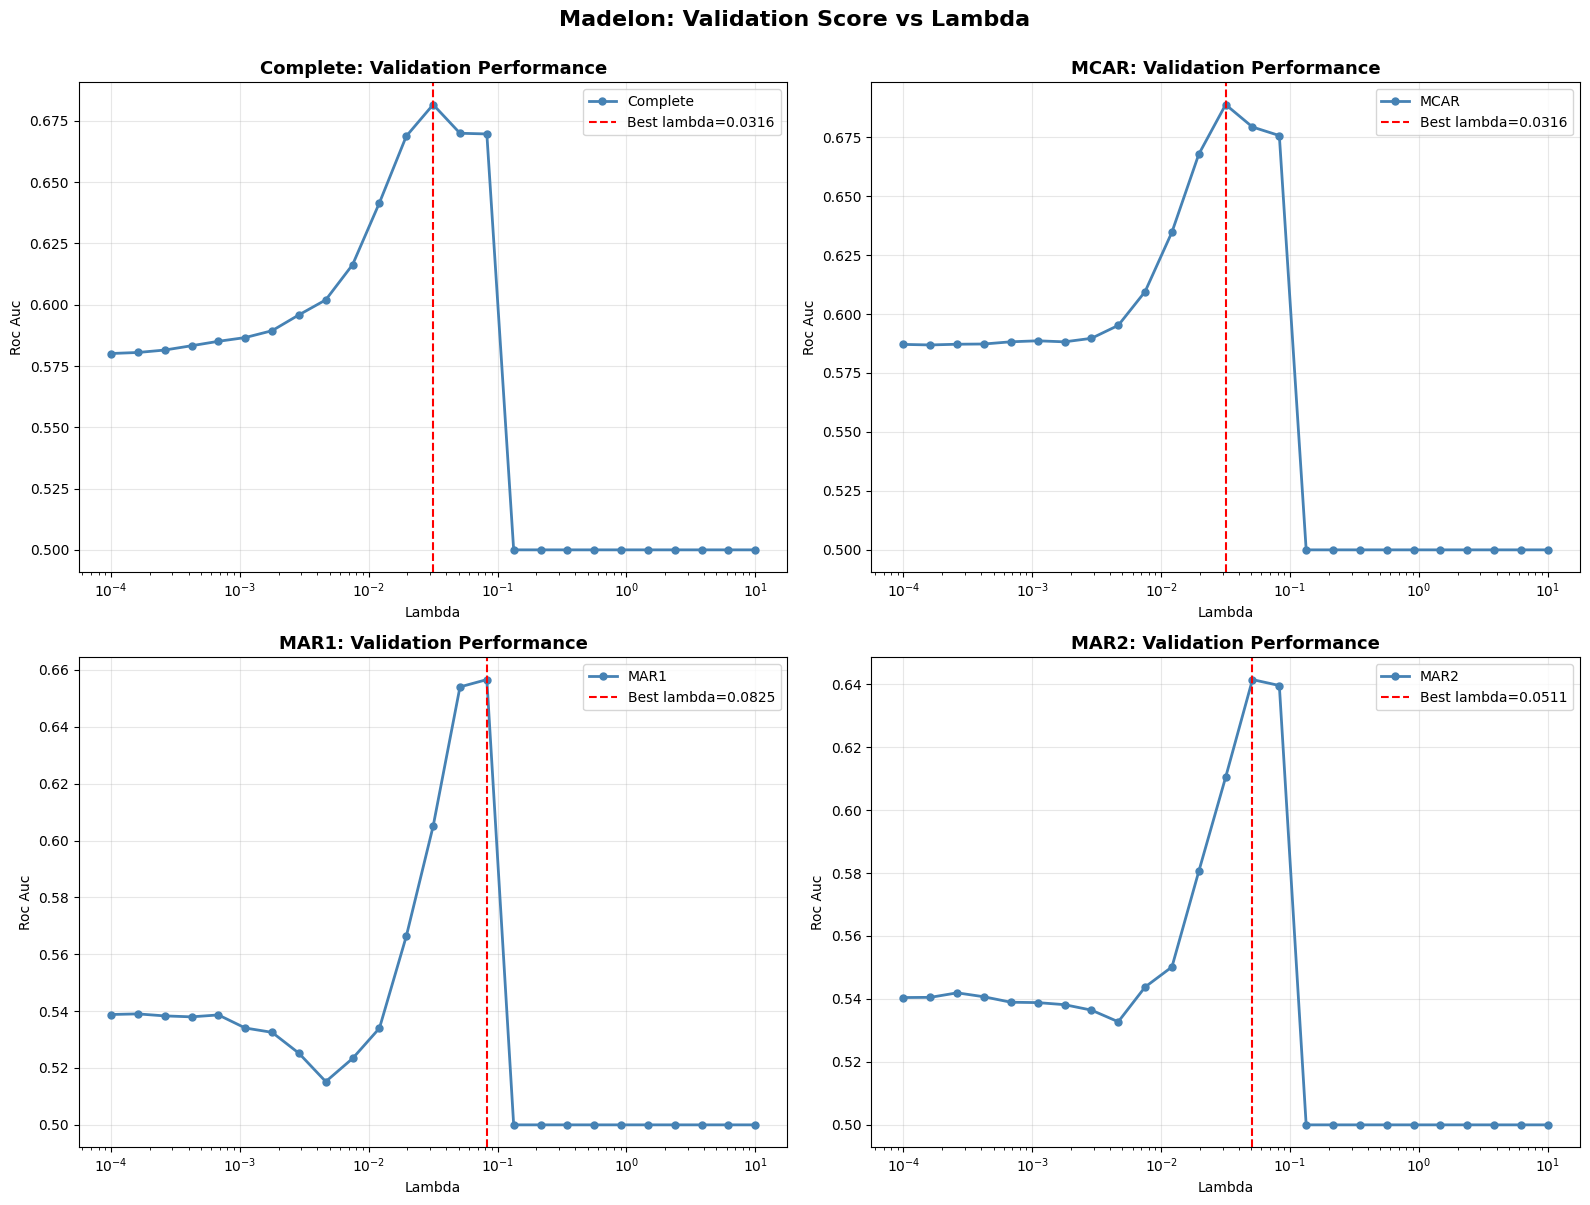

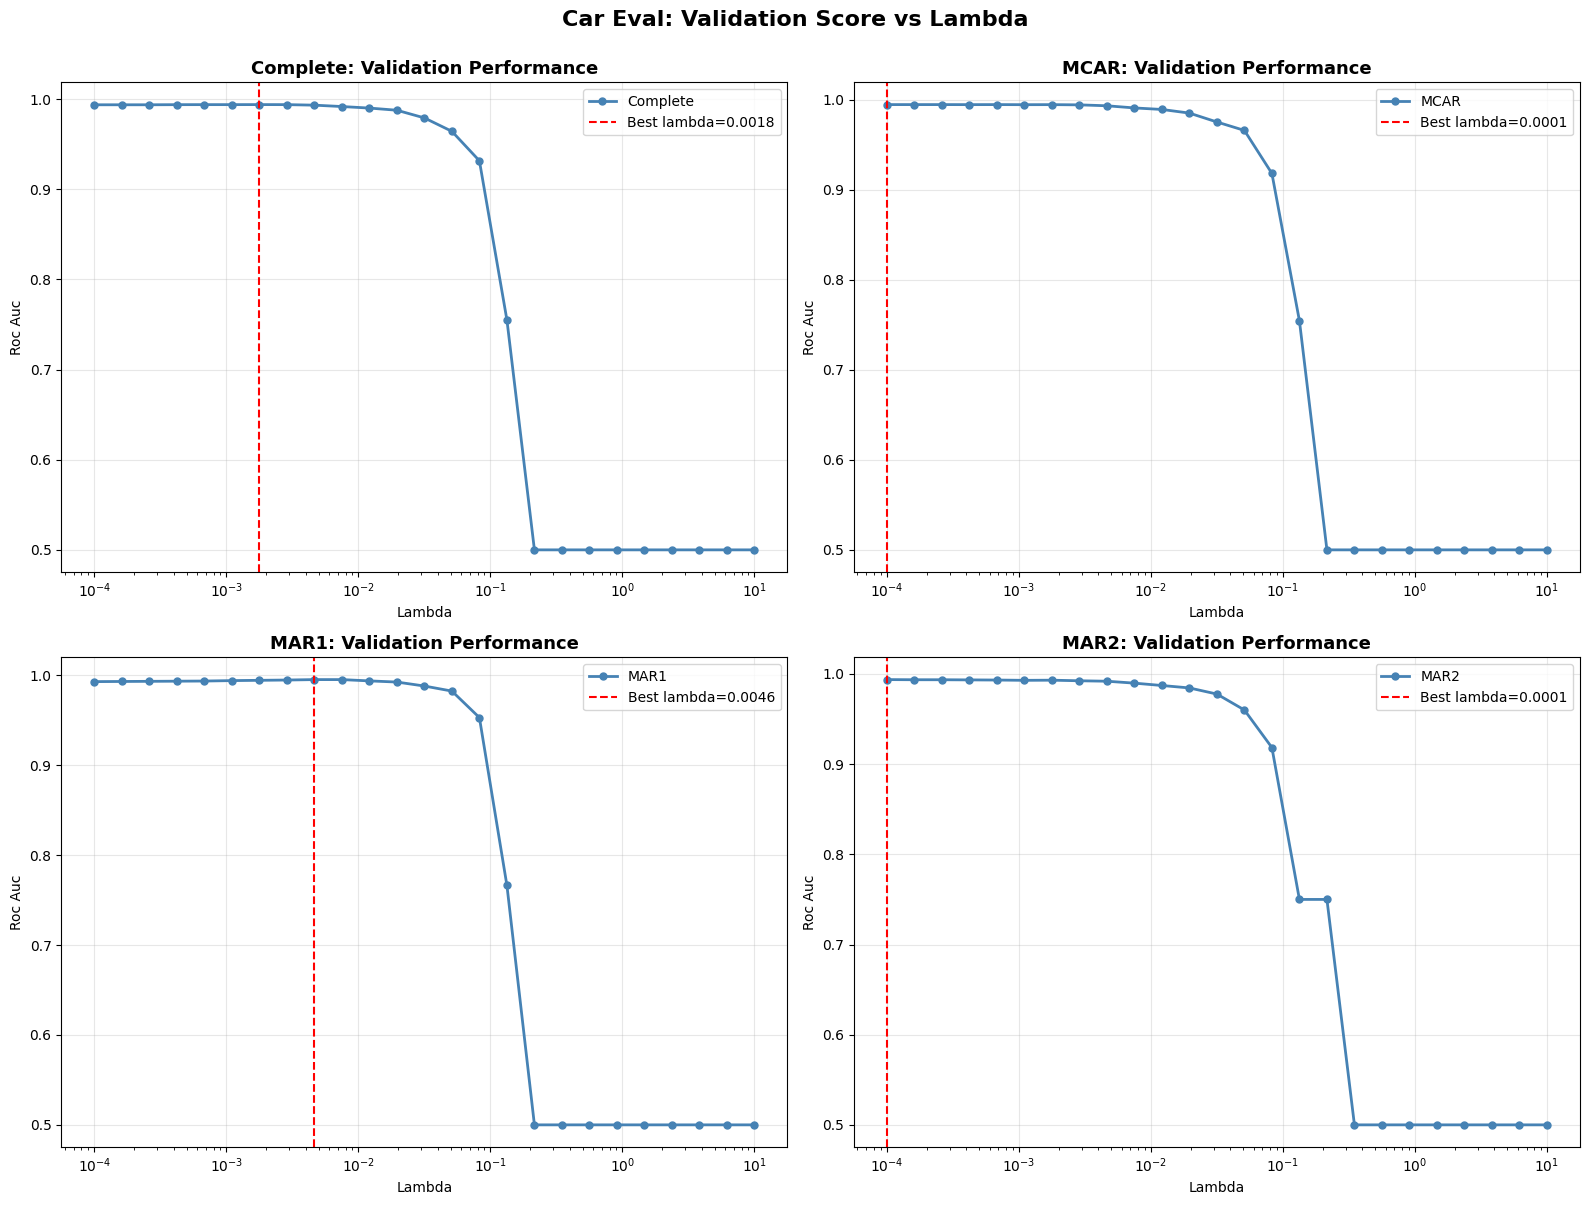

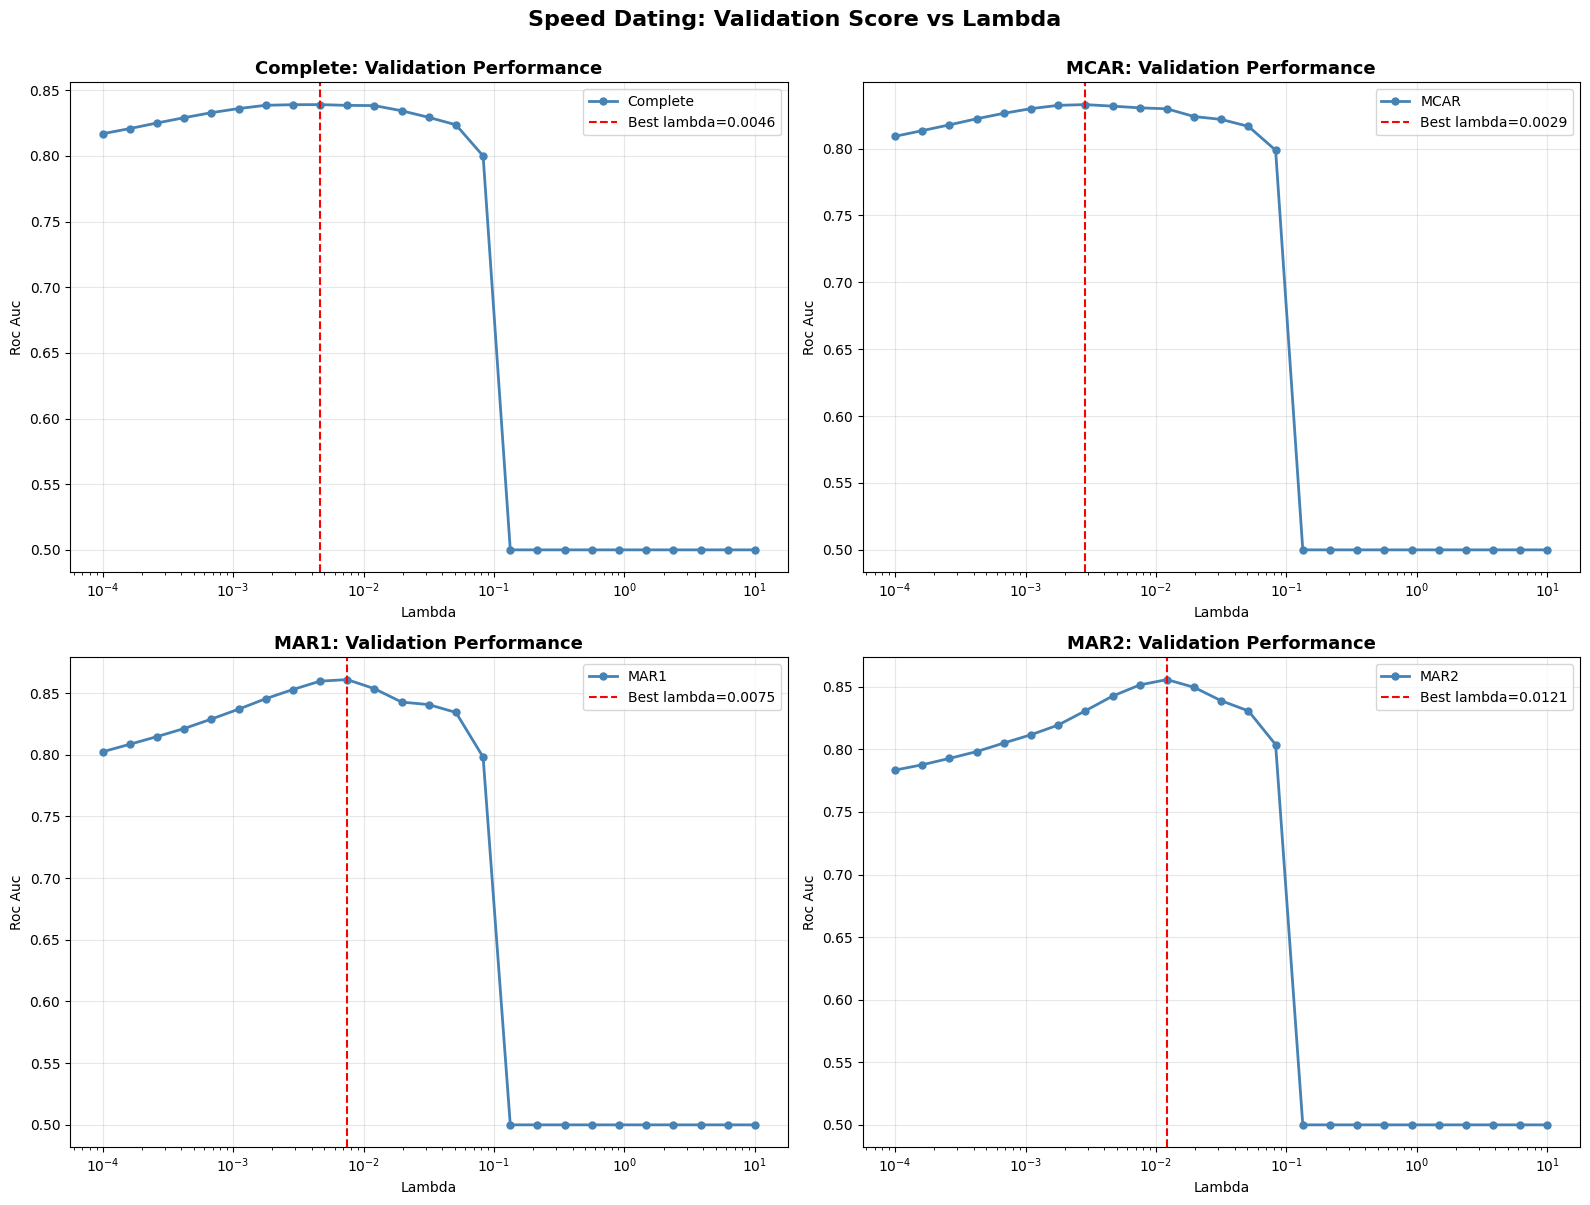

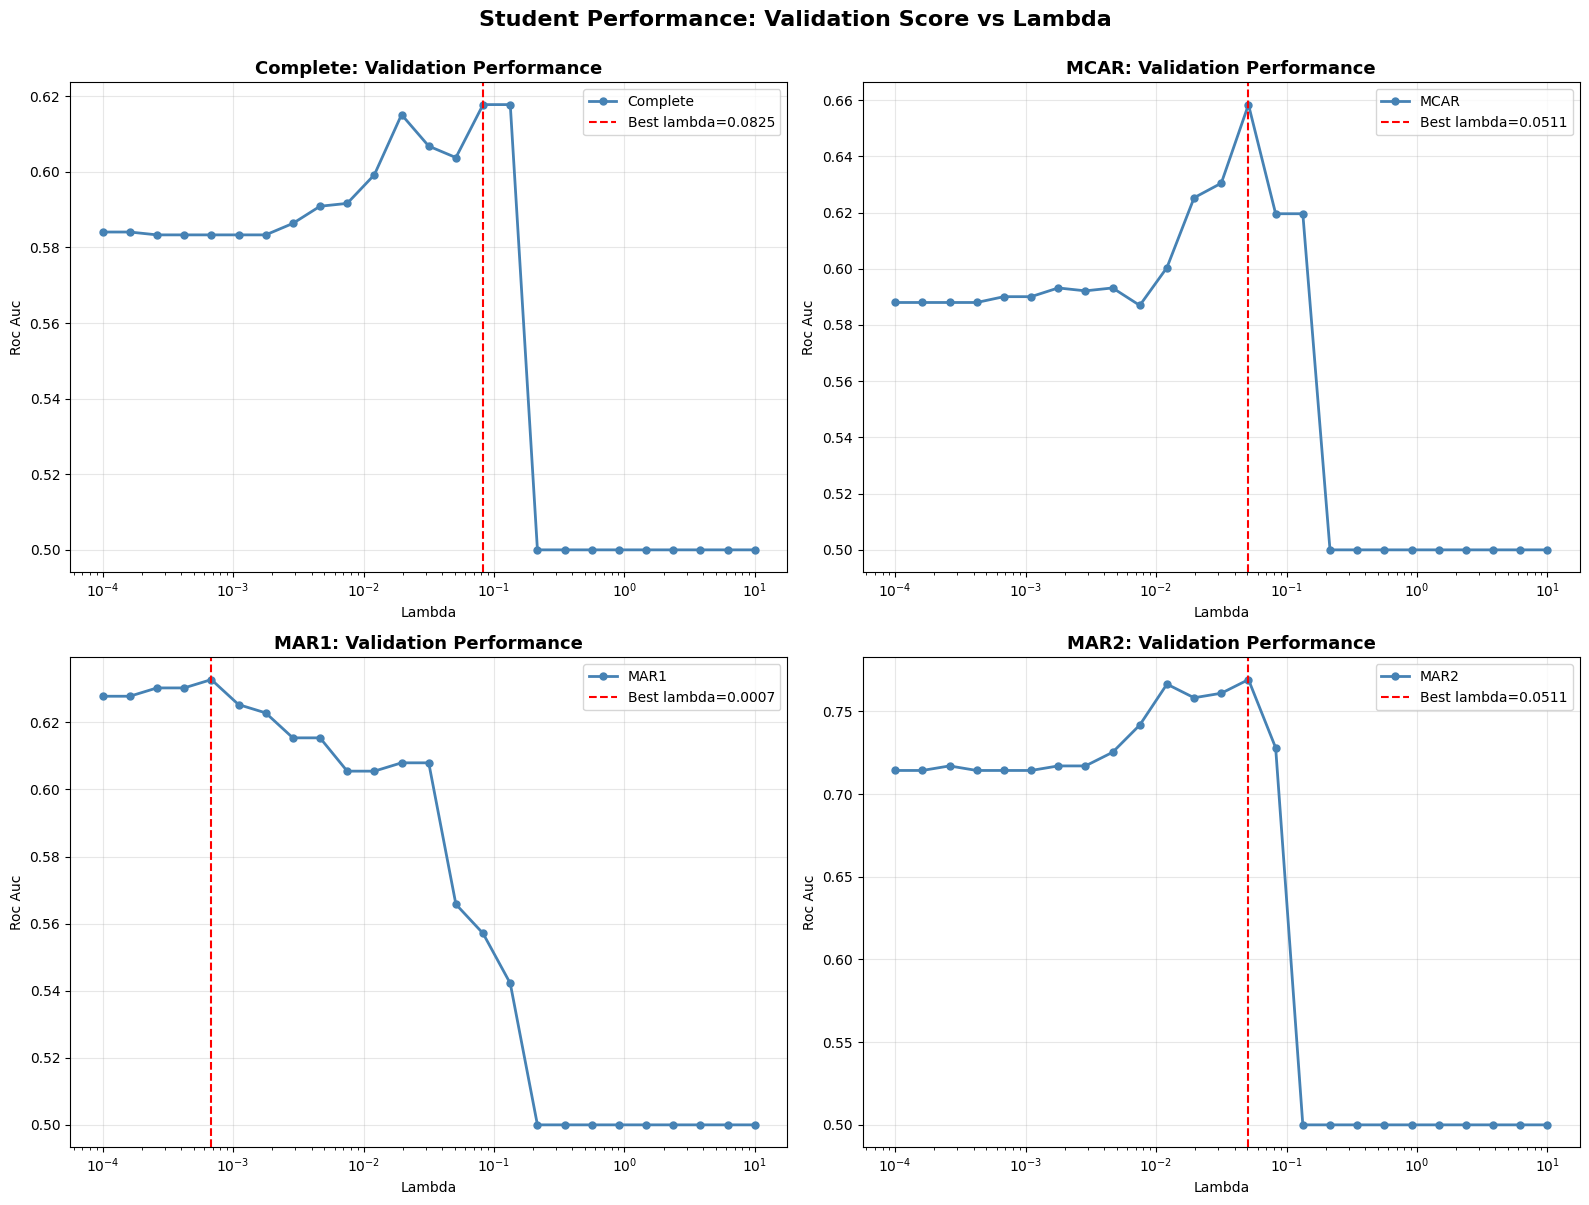

In [34]:
# Visualize validation performance for all datasets
mechanisms_to_plot = ['Complete', 'MCAR', 'MAR1', 'MAR2']

for dataset_name, fista_models_dict in all_fista_models.items():
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, mechanism_name in enumerate(mechanisms_to_plot):
        if mechanism_name in fista_models_dict:
            fista_model = fista_models_dict[mechanism_name]
            fista_model.plot(measure=measure, ax=axes[idx], label=f'{mechanism_name}', color='steelblue')
            axes[idx].set_title(f'{mechanism_name}: Validation Performance', fontsize=13, fontweight='bold')
    
    fig.suptitle(f'{dataset_name}: Validation Score vs Lambda', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


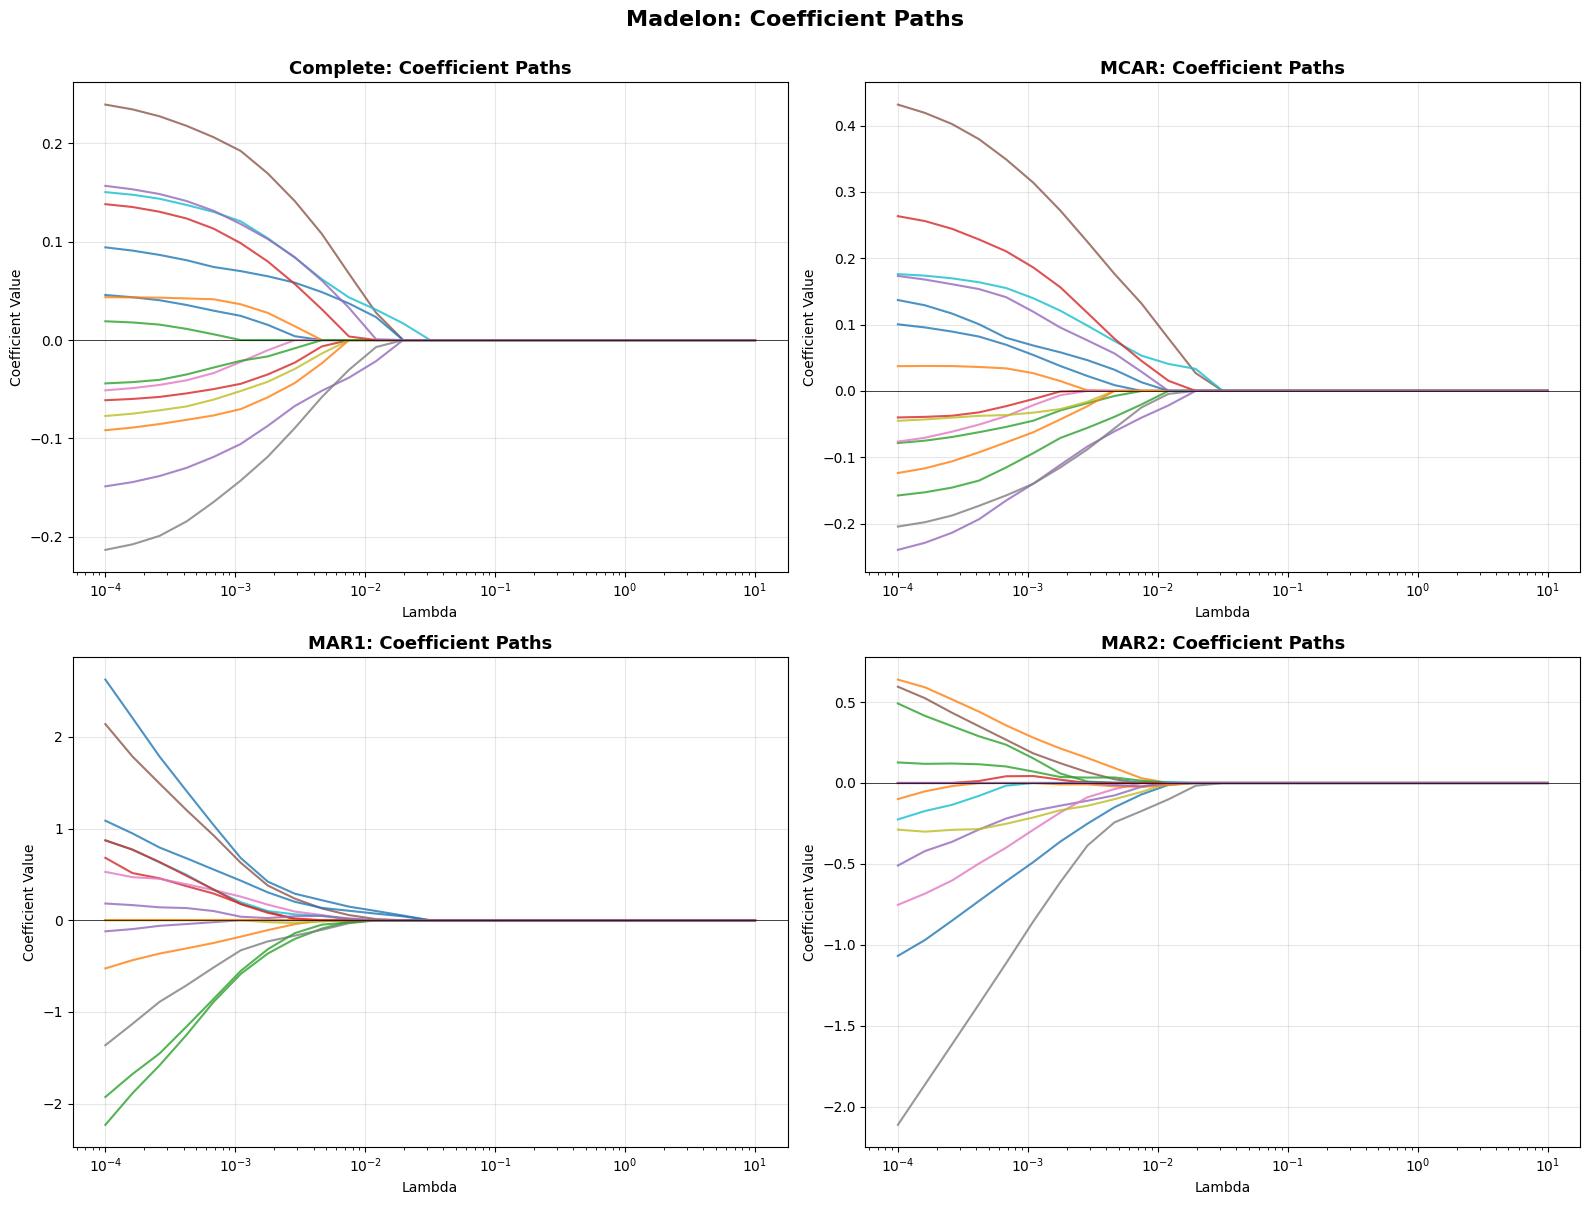

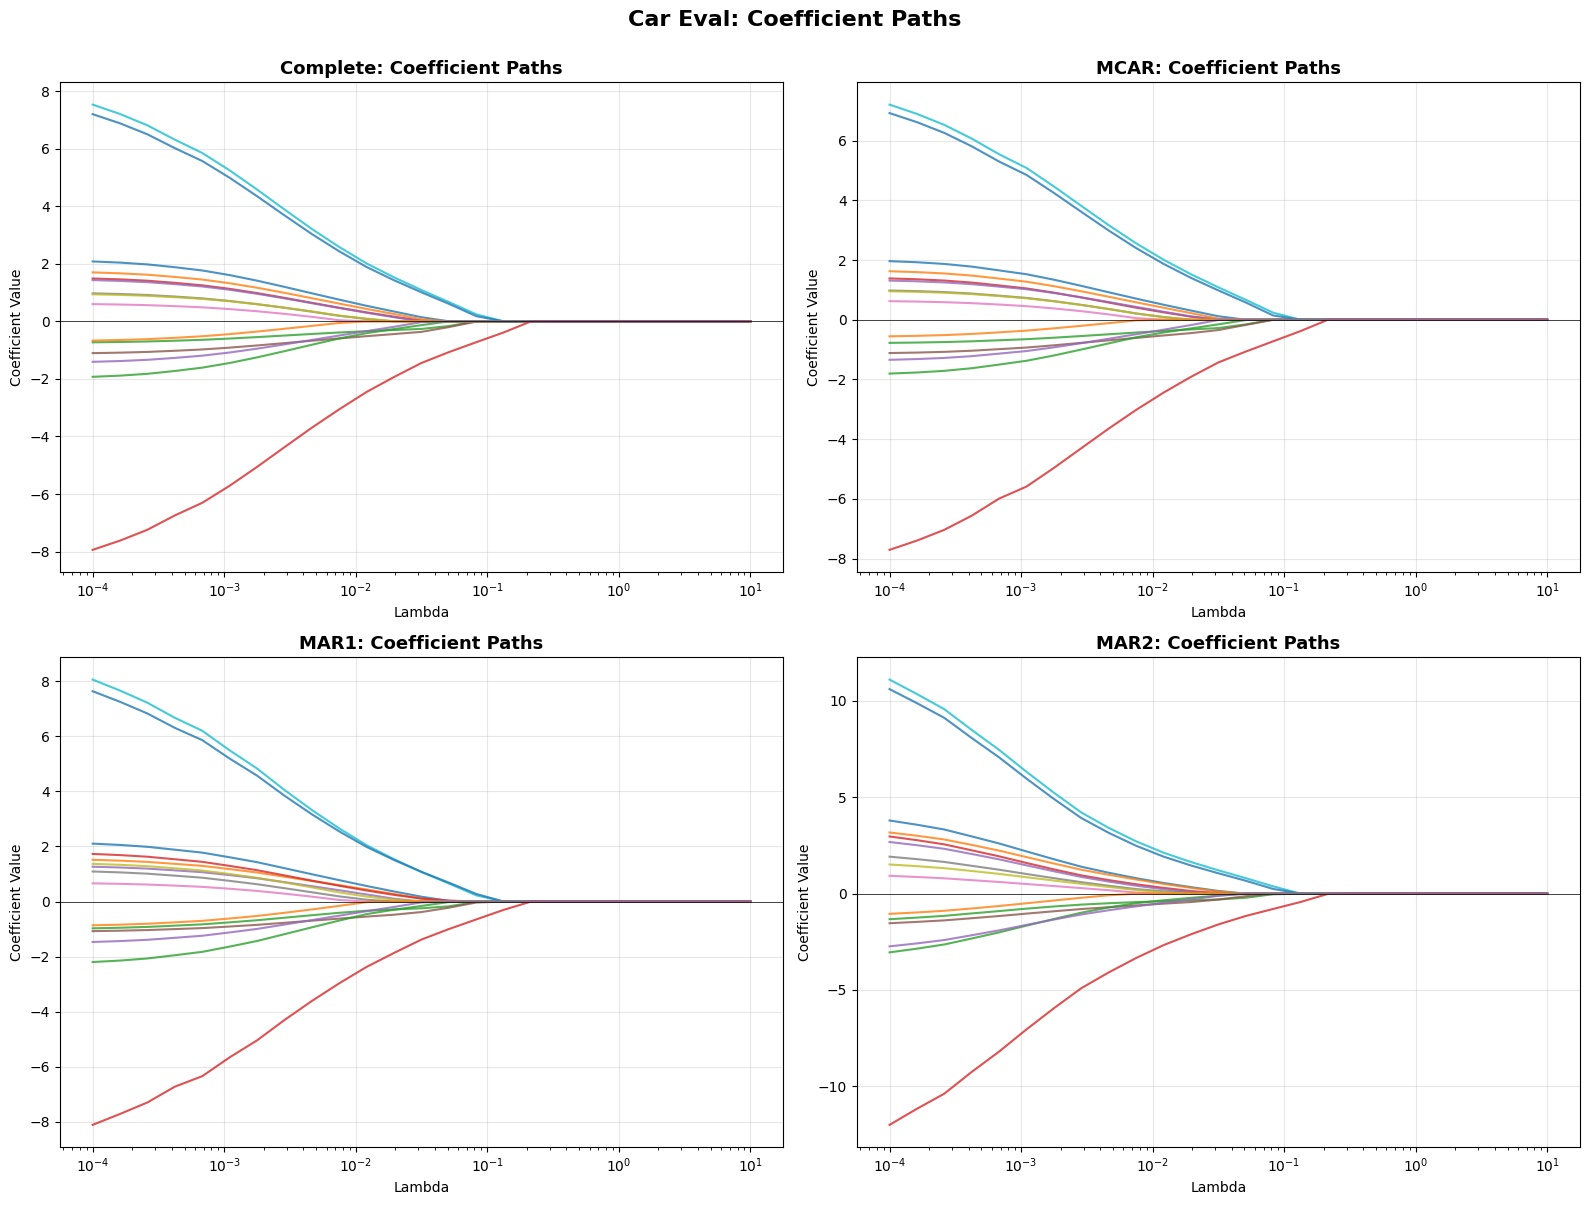

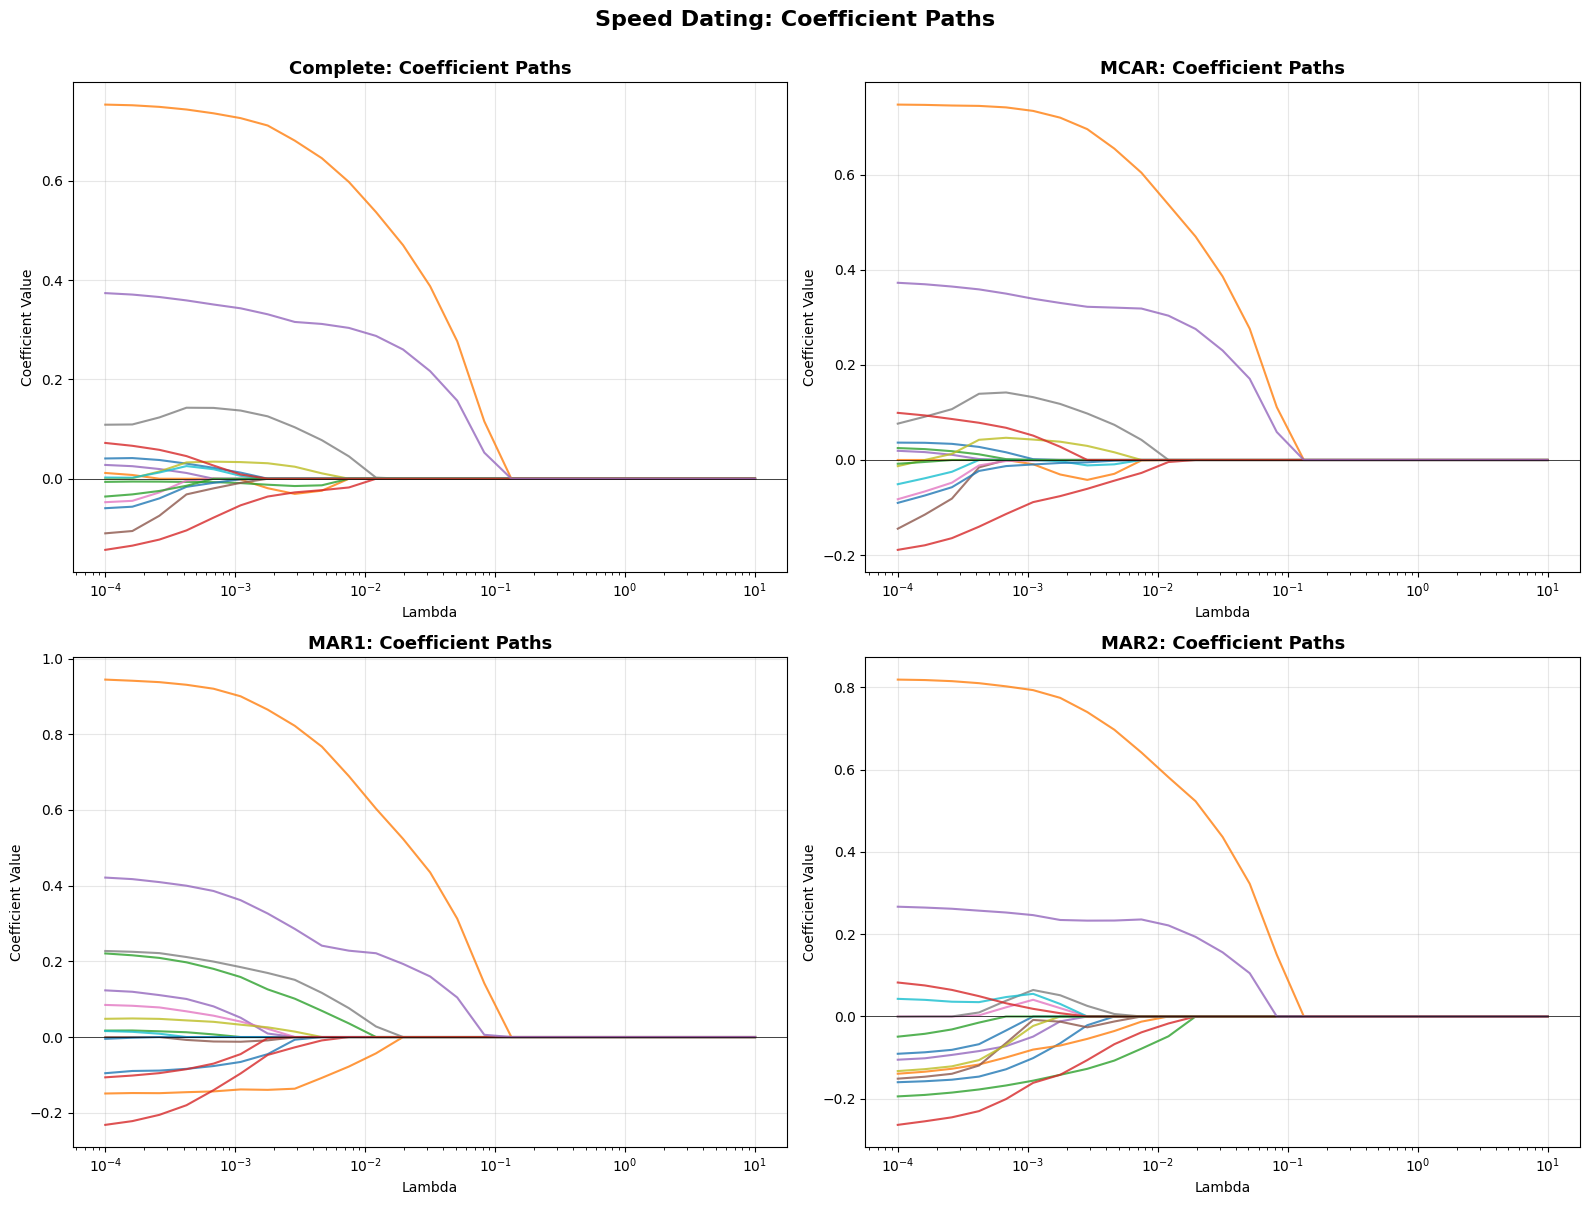

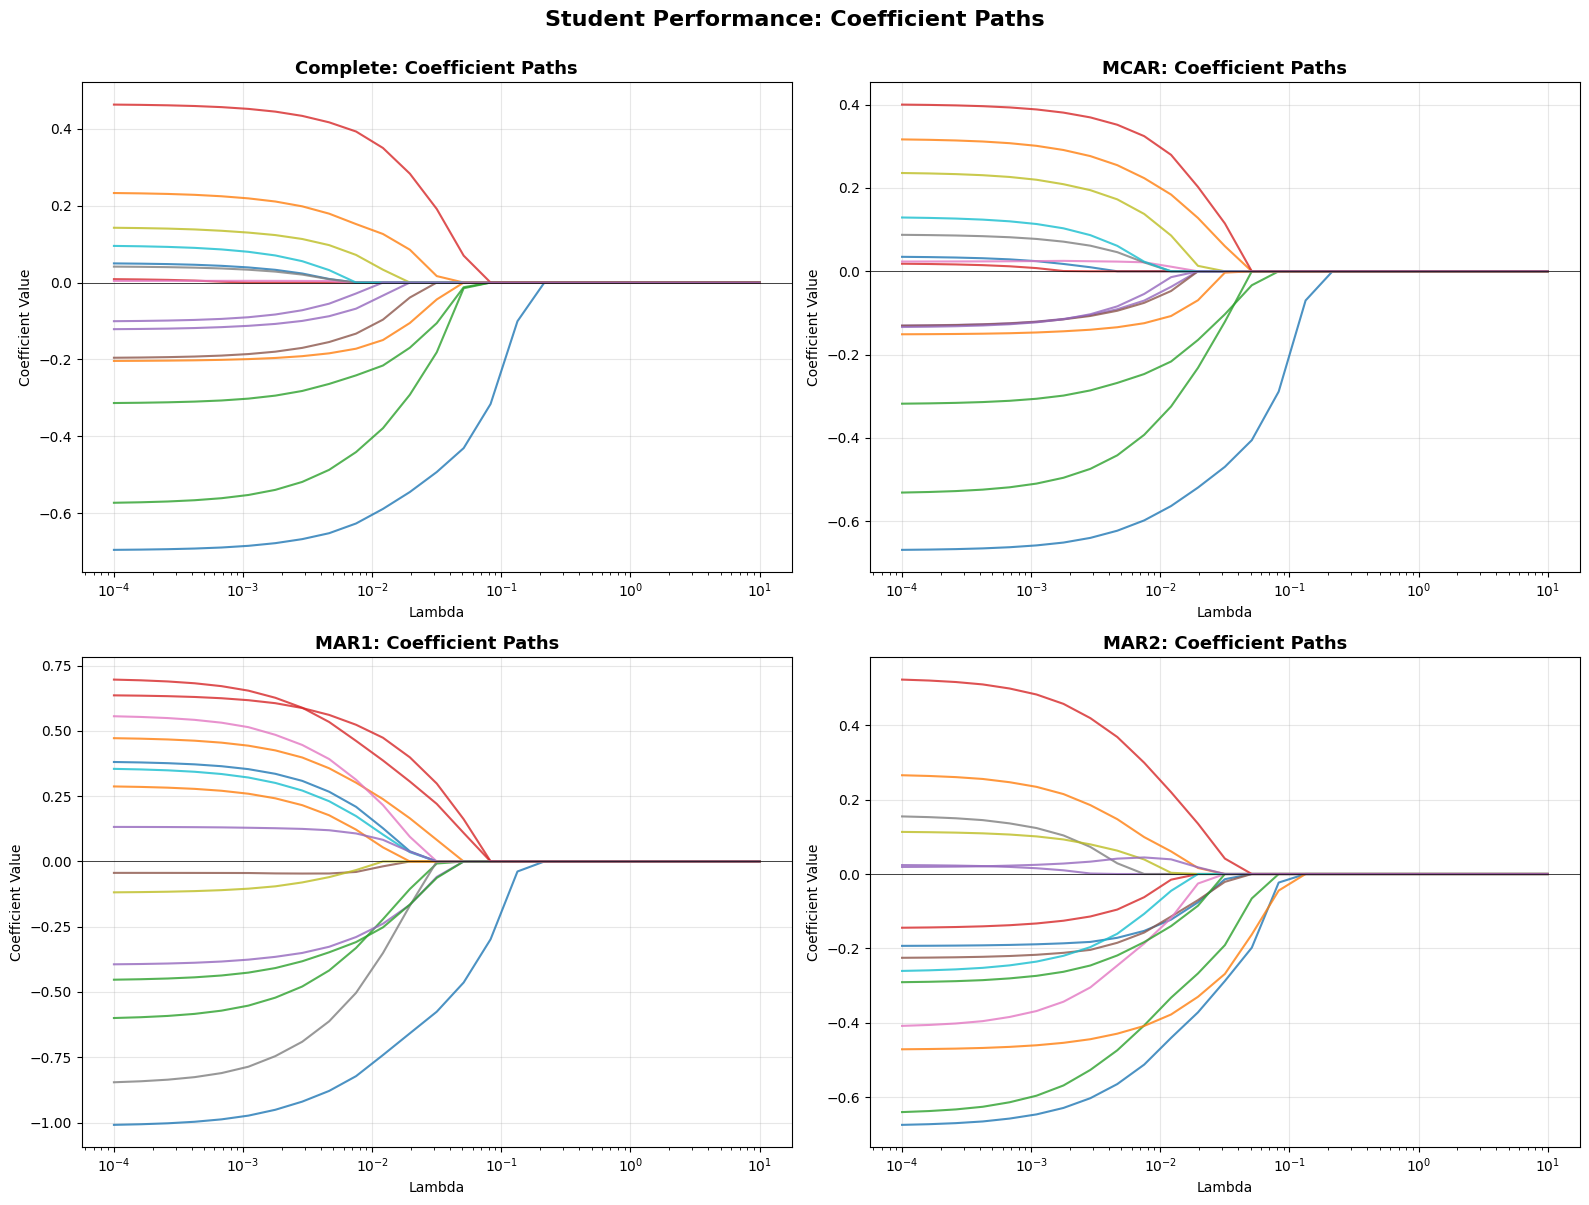

In [35]:
# Visualize coefficient paths for all datasets
mechanisms_to_plot = ['Complete', 'MCAR', 'MAR1', 'MAR2']

for dataset_name, fista_models_dict in all_fista_models.items():
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, mechanism_name in enumerate(mechanisms_to_plot):
        if mechanism_name in fista_models_dict:
            fista_model = fista_models_dict[mechanism_name]
            fista_model.plot_coefficients(ax=axes[idx], top_n=15)
            axes[idx].set_title(f'{mechanism_name}: Coefficient Paths', fontsize=13, fontweight='bold')
    
    fig.suptitle(f'{dataset_name}: Coefficient Paths', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


### Comparison with scikit-learn Implementation

Training sklearn Lasso models on datasets with MCAR mechanism...


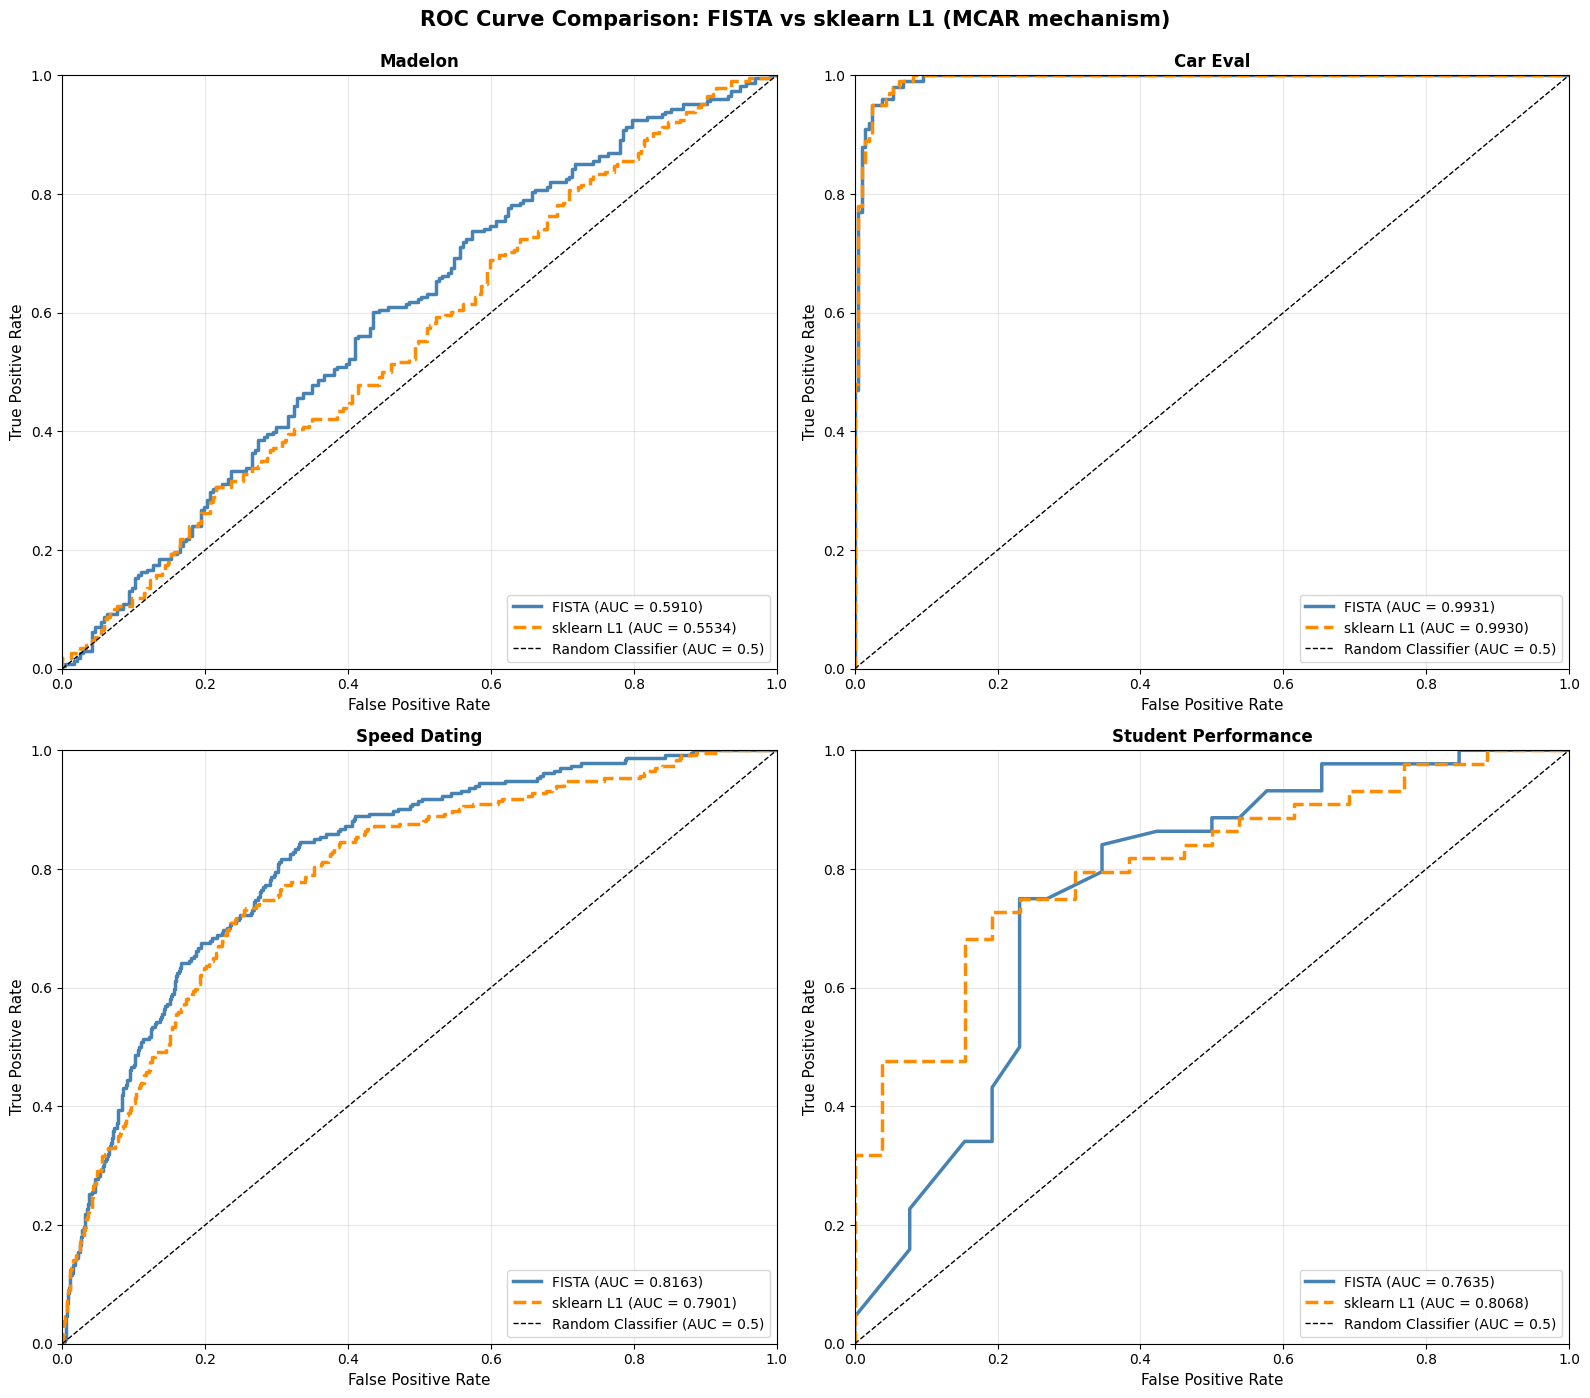

In [36]:
# Compare FISTA with scikit-learn for all datasets and MCAR mechanism
mechanism_to_compare = 'MCAR'
print(f"Training sklearn Lasso models on datasets with {mechanism_to_compare} mechanism...")

comparison_results = {}
roc_data = {}  # Store ROC curves for plotting

for dataset_name, prepared_data in prepared_datasets.items():
    
    X_train = prepared_data['X_train']
    X_valid = prepared_data['X_valid']
    X_test = prepared_data['X_test']
    
    missing_mechanisms = missing_data_by_dataset[dataset_name]
    y_train_mcar, y_valid_mcar, y_test_mcar = missing_mechanisms[mechanism_to_compare]
    
    # Get FISTA model
    fista_mcar = all_fista_models[dataset_name][mechanism_to_compare]
    
    # Filter observed samples
    train_mask = y_train_mcar != -1
    test_mask = y_test_mcar != -1
    
    X_train_obs = X_train[train_mask]
    y_train_obs = y_train_mcar[train_mask]
    X_test_obs = X_test[test_mask]
    y_test_obs = y_test_mcar[test_mask]
    
    # Train sklearn LogisticRegression with L1 penalty
    sklearn_lr = LogisticRegression(penalty='l1', random_state=42, solver='saga', max_iter=5000)
    sklearn_lr.fit(X_train_obs, y_train_obs)
    
    # Get predictions
    fista_proba = fista_mcar.predict_proba(X_test_obs)[:, 1]
    sklearn_proba = sklearn_lr.predict_proba(X_test_obs)[:, 1]
    
    fista_fpr, fista_tpr, _ = roc_curve(y_test_obs, fista_proba)
    sklearn_fpr, sklearn_tpr, _ = roc_curve(y_test_obs, sklearn_proba)
    
    fista_auc = auc(fista_fpr, fista_tpr)
    sklearn_auc = auc(sklearn_fpr, sklearn_tpr)
    
    roc_data[dataset_name] = {
        'fista_fpr': fista_fpr,
        'fista_tpr': fista_tpr,
        'fista_auc': fista_auc,
        'sklearn_fpr': sklearn_fpr,
        'sklearn_tpr': sklearn_tpr,
        'sklearn_auc': sklearn_auc
    }
    


# Plot all ROC curves on one figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

dataset_names = list(roc_data.keys())

for idx, dataset_name in enumerate(dataset_names):
    ax = axes[idx]
    data = roc_data[dataset_name]
    
    ax.plot(data['fista_fpr'], data['fista_tpr'], 
            label=f'FISTA (AUC = {data["fista_auc"]:.4f})', 
            linewidth=2.5, color='steelblue')
    ax.plot(data['sklearn_fpr'], data['sklearn_tpr'], 
            label=f'sklearn L1 (AUC = {data["sklearn_auc"]:.4f})', 
            linewidth=2.5, color='darkorange', linestyle='--')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
    
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{dataset_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

fig.suptitle(f'ROC Curve Comparison: FISTA vs sklearn L1 ({mechanism_to_compare} mechanism)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

